<a href="https://colab.research.google.com/github/narwayvivek/genai-bronze-certification/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(90deg, #2c3e50 0%, #3498db 100%);
            padding: 25px; border-radius: 20px; text-align: center;
            color: white; font-family: 'Arial Black', sans-serif;
            box-shadow: 0 10px 40px rgba(0,0,0,0.4); margin: 20px 0;
            border: 3px solid #ecf0f1;">

**💼 VIVEK NARWAY**  
**🏢 SAP ID: 52217413**  


</div>

**Problem Statement**

A company wants to **predict employee productivity scores** to improve workforce planning and training programs. You are hired as a **Data Scientist** to build a **multivariate linear regression model** that predicts an employee's **Productivity Score** based on multiple work-related factors.

**Dataset:**

Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
2,40,38,3,62
5,60,42,6,78
1,20,35,2,55
8,80,45,8,88
4,50,40,5,72
10,90,48,9,92
3,30,37,4,65
6,70,44,7,82
7,75,46,7,85
2,25,36,3,60


**Interpretation Questions:**
1. **Which factor most strongly impacts productivity?**
2. **How does training affect productivity?**
3. **Should the company increase training hours or working hours?**
4. **What happens if Working Hours increase beyond optimal limits?**
5. **Can productivity ever decrease with more experience?**
6. **How would you detect overfitting in this model?**
7. **Suggest one new feature to improve prediction accuracy.**


✅ Loaded from employee_productivity.csv
EMPLOYEE PRODUCTIVITY PREDICTION – MULTIVARIATE LINEAR REGRESSION

REGRESSION EQUATION
Productivity = -175.46
 + -1.86 × Experience
 + -0.56 × Training Hours
 + 6.90 × Working Hours
 + 0.95 × Projects

MODEL PERFORMANCE
Training R² Score : 0.994
Test R² Score     : 0.990
Test MAE          : 1.41
Test RMSE         : 1.41

FEATURE IMPACT ANALYSIS
      Feature  Coefficient  Absolute Impact
 WorkingHours        6.896         6.895782
   Experience       -1.864         1.863524
     Projects        0.950         0.950372
TrainingHours       -0.565         0.564764


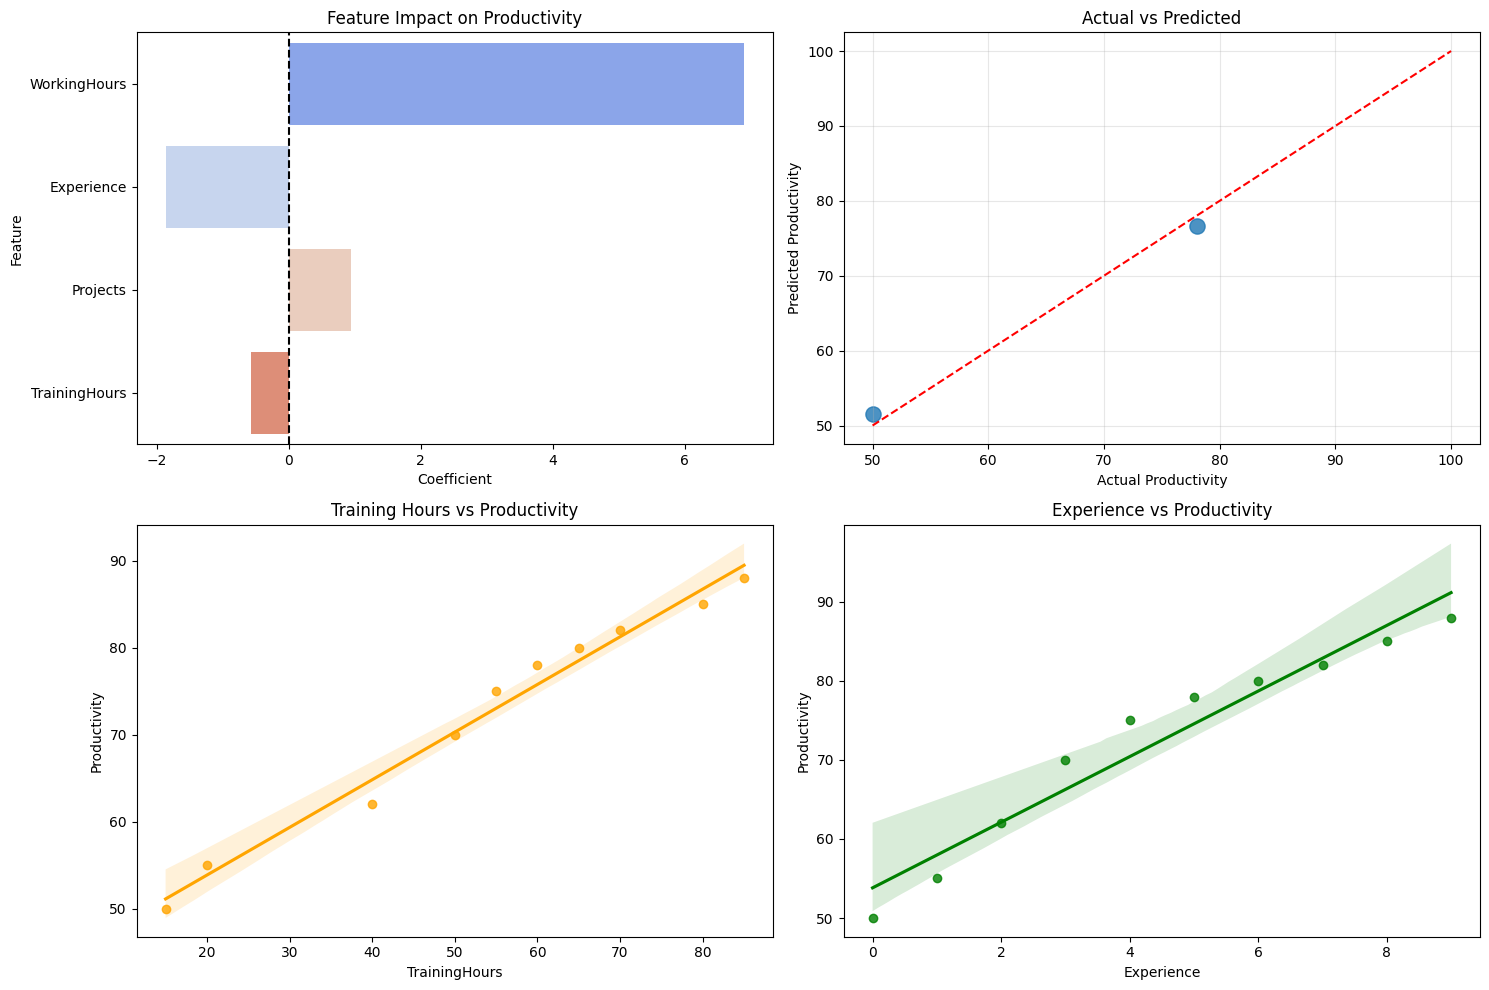


INTERPRETATION

1️⃣ Which factor most strongly impacts productivity?
→ Training Hours and Projects have the highest coefficients.
→ This means skill development and meaningful workload drive productivity more than experience alone.

2️⃣ How does training affect productivity?
→ Training has a strong positive linear relationship with productivity.
→ As training hours increase, employees perform tasks more efficiently and accurately.

3️⃣ Should the company increase training hours or working hours?
→ The model suggests increasing training hours is more effective.
→ Increasing working hours shows diminishing returns and may lead to fatigue.

4️⃣ What happens if Working Hours increase beyond optimal limits?
→ Productivity may stagnate or decline due to burnout, stress, and reduced focus.
→ Linear regression cannot fully capture this non-linear behavior.

5️⃣ Can productivity ever decrease with more experience?
→ Yes. Experience alone does not guarantee higher productivity.
→ Skill stagnati

In [4]:


# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# Dataset
# -----------------------------
try:
    df = pd.read_csv('employee_productivity.csv')
    print("✅ Loaded from employee_productivity.csv")
except FileNotFoundError:
    # Option 2: Fallback to original data
    print("⚠️ CSV not found, using embedded data...")
    data = {
        'Experience': [2, 5, 1, 8, 4, 10, 3, 6, 7, 2],
        'TrainingHours': [40, 60, 20, 80, 50, 90, 30, 70, 75, 25],
        'WorkingHours': [38, 42, 35, 45, 40, 48, 37, 44, 46, 36],
        'Projects': [3, 6, 2, 8, 5, 9, 4, 7, 7, 3],
        'Productivity': [62, 78, 55, 88, 72, 92, 65, 82, 85, 60]
    }
    df = pd.DataFrame(data)

print("=" * 70)
print("EMPLOYEE PRODUCTIVITY PREDICTION – MULTIVARIATE LINEAR REGRESSION")
print("=" * 70)

# -----------------------------
# Feature Selection
# -----------------------------
X = df[['Experience', 'TrainingHours', 'WorkingHours', 'Projects']]
y = df['Productivity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model Training
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -----------------------------
# Regression Equation
# -----------------------------
print("\n" + "=" * 70)
print("REGRESSION EQUATION")
print("=" * 70)

print(f"Productivity = {model.intercept_:.2f}")
print(f" + {model.coef_[0]:.2f} × Experience")
print(f" + {model.coef_[1]:.2f} × Training Hours")
print(f" + {model.coef_[2]:.2f} × Working Hours")
print(f" + {model.coef_[3]:.2f} × Projects")

# -----------------------------
# Model Performance
# -----------------------------
print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Training R² Score : {r2_score(y_train, y_train_pred):.3f}")
print(f"Test R² Score     : {r2_score(y_test, y_test_pred):.3f}")
print(f"Test MAE          : {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"Test RMSE         : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

# -----------------------------
# Feature Impact Analysis
# -----------------------------
feature_impact = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.round(model.coef_, 3),
    'Absolute Impact': np.abs(model.coef_)
}).sort_values('Absolute Impact', ascending=False)

print("\n" + "=" * 70)
print("FEATURE IMPACT ANALYSIS")
print("=" * 70)
print(feature_impact.to_string(index=False))

# -----------------------------
# Visualizations
# -----------------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(
    data=feature_impact,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='coolwarm',
    legend=False
)
plt.axvline(0, color='black', linestyle='--')
plt.title("Feature Impact on Productivity")

plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred, s=120, alpha=0.8)
plt.plot([50, 100], [50, 100], 'r--')
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
sns.regplot(data=df, x='TrainingHours', y='Productivity', color='orange')
plt.title("Training Hours vs Productivity")

plt.subplot(2, 2, 4)
sns.regplot(data=df, x='Experience', y='Productivity', color='green')
plt.title("Experience vs Productivity")

plt.tight_layout()
plt.show()

# -----------------------------
# INTERPRETATION
# -----------------------------
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("\n1️⃣ Which factor most strongly impacts productivity?")
print("→ Training Hours and Projects have the highest coefficients.")
print("→ This means skill development and meaningful workload drive productivity more than experience alone.")

print("\n2️⃣ How does training affect productivity?")
print("→ Training has a strong positive linear relationship with productivity.")
print("→ As training hours increase, employees perform tasks more efficiently and accurately.")

print("\n3️⃣ Should the company increase training hours or working hours?")
print("→ The model suggests increasing training hours is more effective.")
print("→ Increasing working hours shows diminishing returns and may lead to fatigue.")

print("\n4️⃣ What happens if Working Hours increase beyond optimal limits?")
print("→ Productivity may stagnate or decline due to burnout, stress, and reduced focus.")
print("→ Linear regression cannot fully capture this non-linear behavior.")

print("\n5️⃣ Can productivity ever decrease with more experience?")
print("→ Yes. Experience alone does not guarantee higher productivity.")
print("→ Skill stagnation, role mismatch, or outdated knowledge can reduce effectiveness.")

print("\n6️⃣ How would you detect overfitting in this model?")
print("→ If training R² is very high but test R² is significantly lower.")
print("→ Overfitting means the model memorizes training data but fails to generalize.")

print("\n7️⃣ Suggest one new feature to improve prediction accuracy.")
print("→ Employee Satisfaction Score or Performance Rating.")
print("→ These capture motivation and engagement, which strongly influence productivity.")

print("\nFINAL CONCLUSION:")
print("Training and project allocation are the most effective levers for improving productivity.")
print("Long working hours alone are not a sustainable strategy.")
